In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

df = pl.read_parquet("out/*.parquet")

df

iterations,invalidation_method,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg,iter,inv
i64,i64,i64,i64,i64,i64,i64,i32,str,str,str,str
10,1,1,280,4096,9149,5902,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,2,504,4096,6484,5024,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,3,676,4096,7227,5895,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,4,320,4096,6083,4793,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,5,1284,4096,9288,6350,1,"""ollama""","""WKdm""","""10""","""clflush"""
…,…,…,…,…,…,…,…,…,…,…,…
10,0,455,1161,4096,25306,8331,1,"""work-small""","""zstd""","""10""","""none"""
10,0,456,939,4096,23854,11498,1,"""work-small""","""zstd""","""10""","""none"""
10,0,457,1553,4096,25786,10620,1,"""work-small""","""zstd""","""10""","""none"""


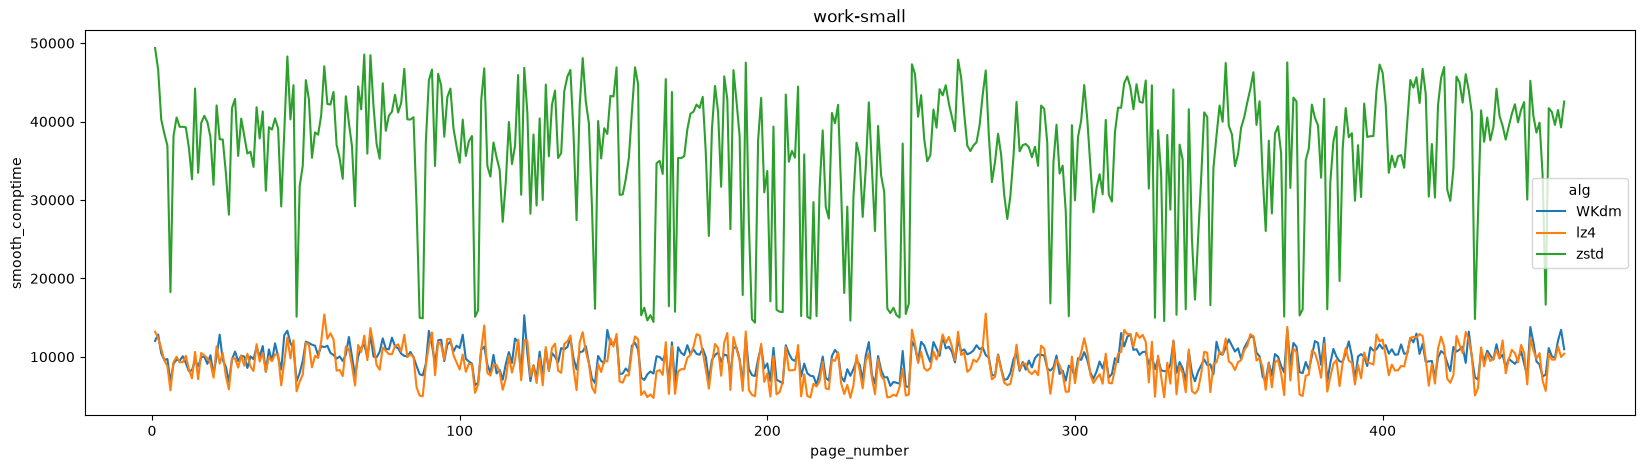

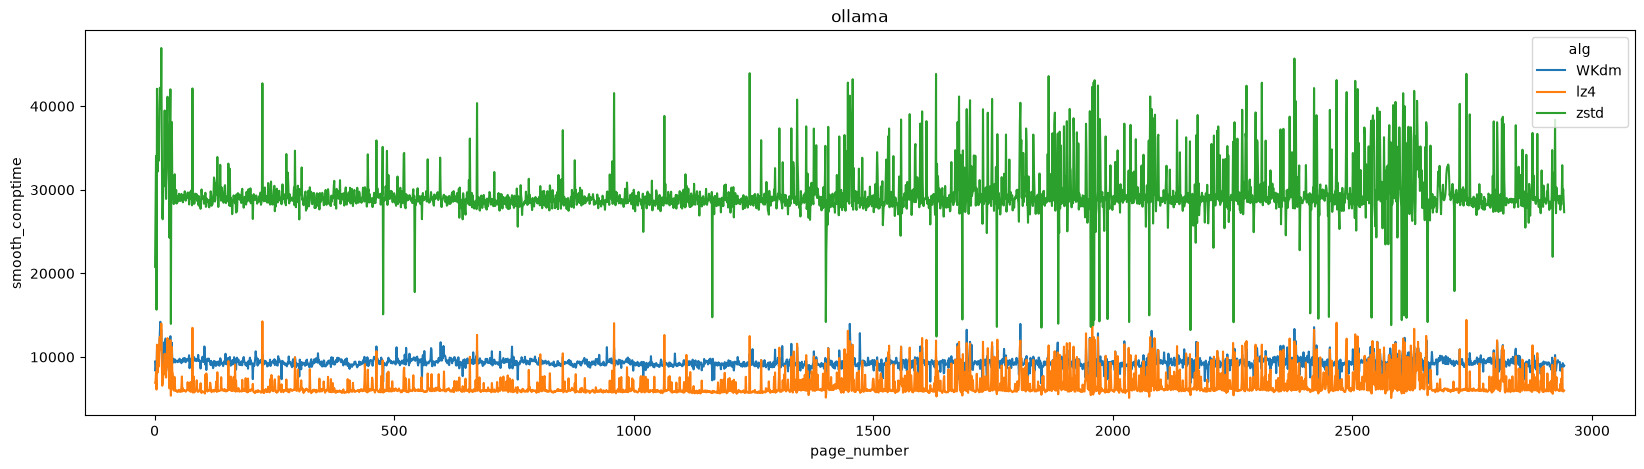

In [17]:
df1 = df.filter(
    pl.col("invalidation_method") == 2
).with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=1)
    .over("alg")
    .alias("smooth_comptime")
)

for trace in df["trace"].unique().to_list():
    plt.figure(figsize=(20,5))
    ax = sns.lineplot(
        df1.filter(pl.col("trace") == trace),
        x="page_number",
        y="smooth_comptime",
        hue="alg"
    )
    ax.set_title(trace)

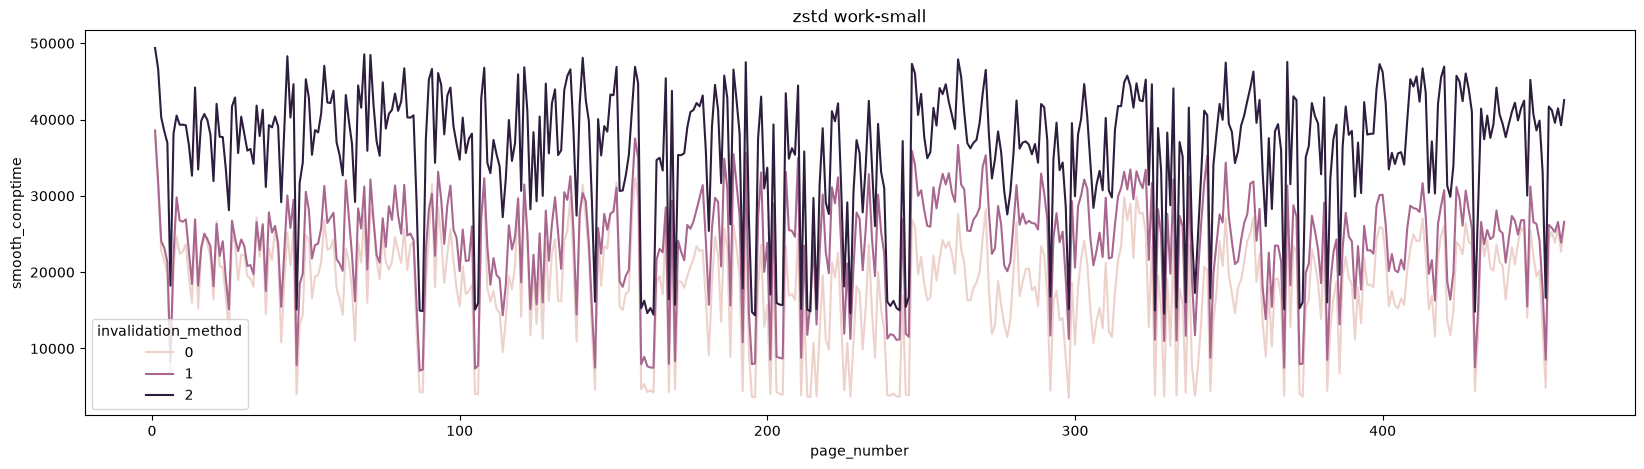

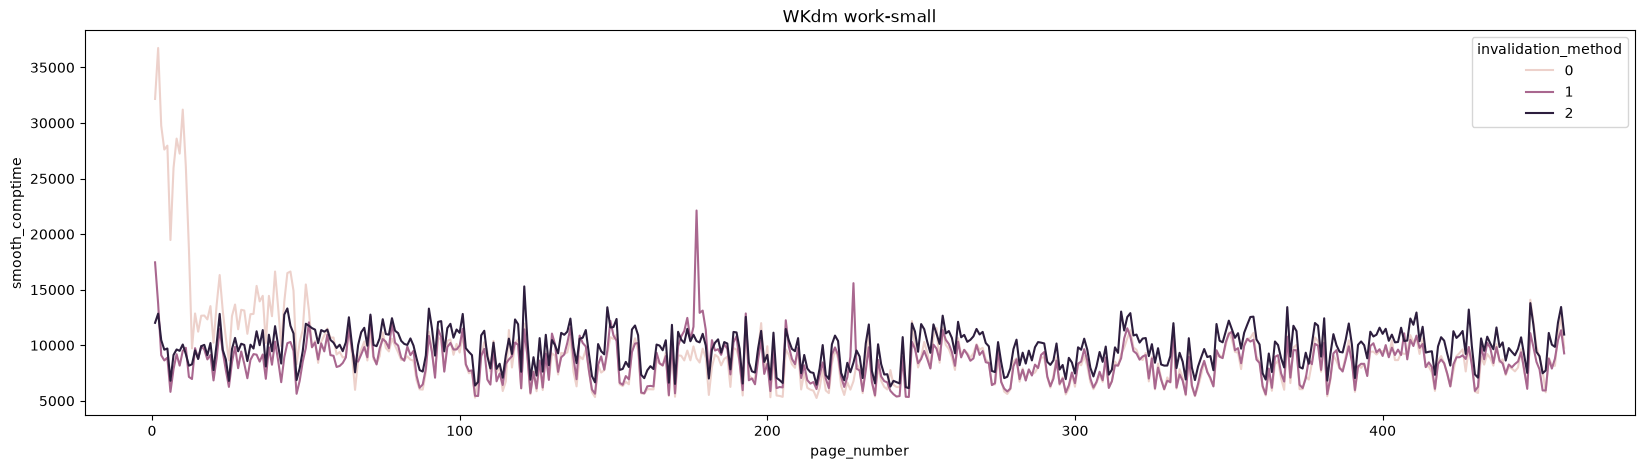

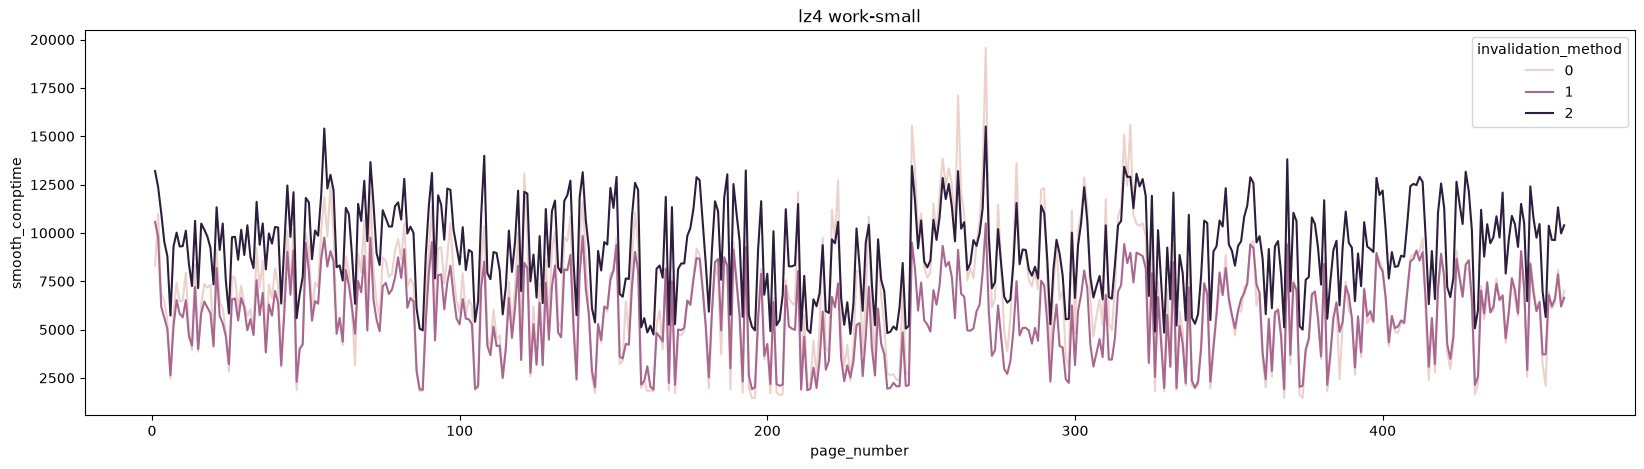

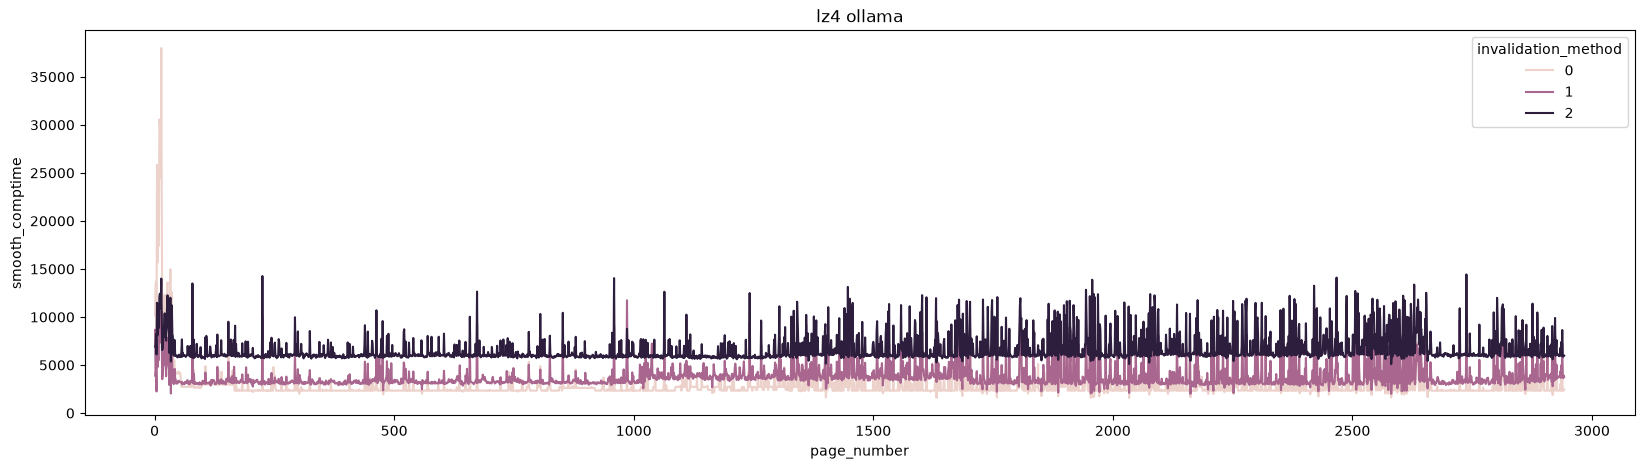

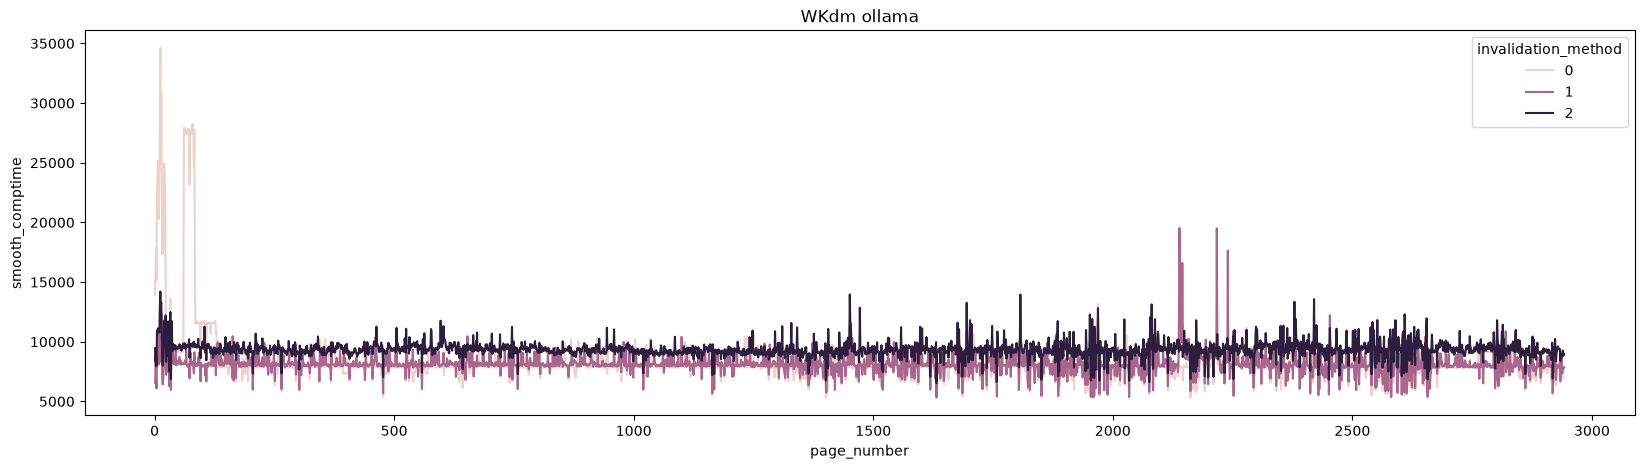

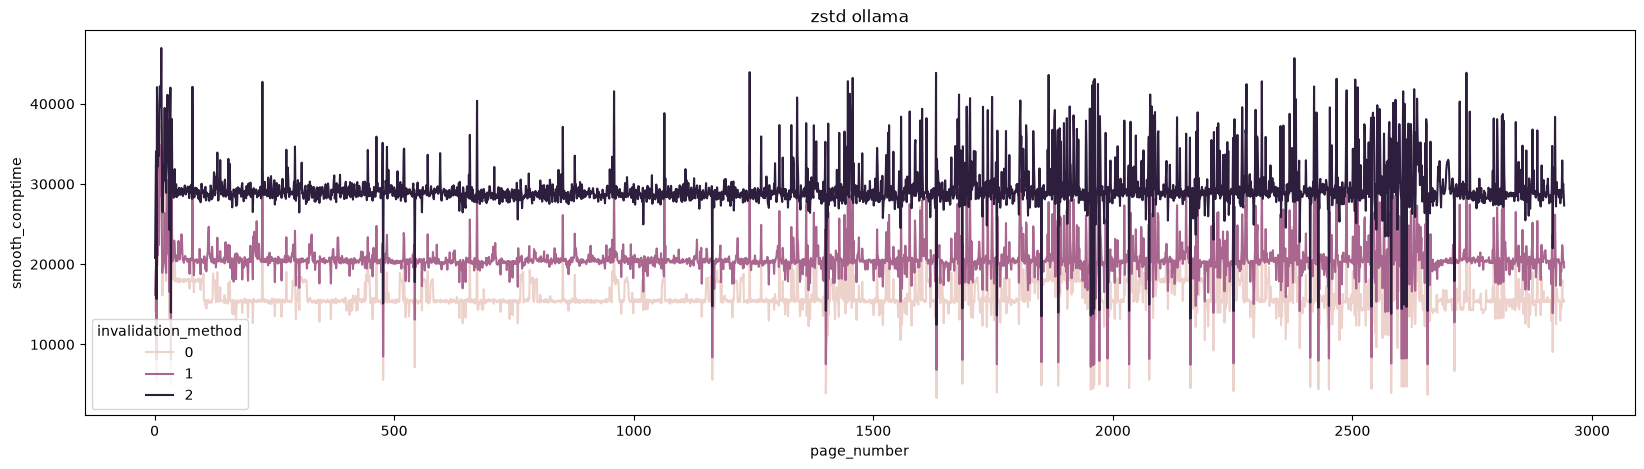

In [8]:

df1 = df.with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=1)
    .over(["alg", "invalidation_method"])
    .alias("smooth_comptime")
)

for trace in df["trace"].unique().to_list():
    for alg in df["alg"].unique().to_list():
        plt.figure(figsize=(20,5))
        ax = sns.lineplot(
            df1.filter(
                pl.col("trace") == trace,
                pl.col("alg") == alg
                ),
            x="page_number",
            y="smooth_comptime",
            hue="invalidation_method"
        )
        ax.set_title(f"{alg} {trace}")

In [10]:
for trace in df1["trace"].unique().to_list():
    res = (
        df1
        .filter(pl.col("trace") == trace)
        .group_by("alg")
        .agg(
            [
                pl.col("smooth_comptime")
                .filter(pl.col("invalidation_method") == 0)
                .mean()
                .alias("mean_0"),
                pl.col("smooth_comptime")
                .filter(pl.col("invalidation_method") == 1)
                .mean()
                .alias("mean_1"),
                pl.col("smooth_comptime")
                .filter(pl.col("invalidation_method") == 2)
                .mean()
                .alias("mean_2"),
            ]
        )
        .with_columns(
            (100 * pl.col("mean_1") / pl.col("mean_0")).alias("pct_1_of_0"),
            (100 * pl.col("mean_2") / pl.col("mean_0")).alias("pct_2_of_0"),
        )
    )
    print(trace)
    print(res)
    print()

work-small
shape: (3, 6)
┌──────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┐
│ alg  ┆ mean_0       ┆ mean_1       ┆ mean_2       ┆ pct_1_of_0 ┆ pct_2_of_0 │
│ ---  ┆ ---          ┆ ---          ┆ ---          ┆ ---        ┆ ---        │
│ str  ┆ f64          ┆ f64          ┆ f64          ┆ f64        ┆ f64        │
╞══════╪══════════════╪══════════════╪══════════════╪════════════╪════════════╡
│ zstd ┆ 18351.313725 ┆ 23860.331155 ┆ 36101.363834 ┆ 130.019744 ┆ 196.723594 │
│ WKdm ┆ 9225.875817  ┆ 8582.27451   ┆ 9774.71024   ┆ 93.023954  ┆ 105.94886  │
│ lz4  ┆ 6650.864924  ┆ 5683.030501  ┆ 9186.742919  ┆ 85.447992  ┆ 138.128545 │
└──────┴──────────────┴──────────────┴──────────────┴────────────┴────────────┘

ollama
shape: (3, 6)
┌──────┬──────────────┬─────────────┬──────────────┬────────────┬────────────┐
│ alg  ┆ mean_0       ┆ mean_1      ┆ mean_2       ┆ pct_1_of_0 ┆ pct_2_of_0 │
│ ---  ┆ ---          ┆ ---         ┆ ---          ┆ ---        ┆ ---      